In [1]:
# Imports
from scipy.io import loadmat
import pandas as pd
import numpy as np
import plotly.express as px
import torch.nn as nn
import torch
import itertools
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

cuda
True
NVIDIA GeForce RTX 4070 Ti SUPER


In [3]:
data = loadmat('Xtrain.mat')

In [4]:
def data_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    normalized = df/255
    return normalized
    
def slices(s: pd.Series, slice_length) -> tuple[pd.Series, pd.Series]:
    slices = [window for window in s.rolling(window=slice_length+1)]
    res = [(slc.iloc[:-1], slc.iloc[-1]) for slc in slices[slice_length:]]
    return res

def cv_split(X: np.ndarray, Y: np.ndarray, n_splits=5, gap=0, overlap=False) -> list[tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, int, int]]:
    split_size = len(X) // n_splits
    splits = []
    for i in range(n_splits):
        start = i * split_size
        end = (i + 1) * split_size if i < n_splits - 1 else len(X)

        train_left_end = max(0, start - gap)
        train_right_start = min(len(X), end + gap)

        X_train = np.concatenate((X[:train_left_end], X[train_right_start:]), axis=0)
        Y_train = np.concatenate((Y[:train_left_end], Y[train_right_start:]), axis=0)
        X_val = X[start:end]
        Y_val = Y[start:end]
        splits.append((X_train, Y_train, X_val, Y_val, start, end))
        if i < n_splits - 1 and overlap:
            intermediate_start = (end - start) // 2 + start
            intermediate_end = intermediate_start + split_size

            train_left_end = max(0, intermediate_start - gap)
            train_right_start = min(len(X), intermediate_end + gap)

            X_train = np.concatenate((X[:train_left_end], X[train_right_start:]), axis=0)
            Y_train = np.concatenate((Y[:train_left_end], Y[train_right_start:]), axis=0)
            X_val = X[intermediate_start:intermediate_end]
            Y_val = Y[intermediate_start:intermediate_end]
            splits.append((X_train, Y_train, X_val, Y_val, intermediate_start, intermediate_end))
    return splits

In [5]:
class BaselineNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, output_size=1):
        super().__init__()

        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size),
            nn.Sigmoid() # since we normalized the data to [0,1]
        )

    def forward(self, x):
        x = self.flatten(x)
        out = self.linear_relu_stack(x)

        return out

In [6]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True # needed because we have (batch_size, seq_len, 1). So batch size is given first
        )
        
        self.fc = nn.Linear(hidden_size, 1) # Connects final layer to output

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)

        # pass through model
        out, _ = self.lstm(x)

        # out contains hidden states for all timesteps:
        # shape: (batch_size, seq_len, hidden_size)
        
        # we only care about last timestep.
        out = out[:, -1, :] #takes last timestep
        out = self.fc(out) # gets prediction
        
        return out

In [7]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        
        self.lstm = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True # needed because we have (batch_size, seq_len, 1). So batch size is given first
        )
        
        self.fc = nn.Linear(hidden_size, 1) # Connects final layer to output

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)

        # pass through model
        out, _ = self.lstm(x)

        # out contains hidden states for all timesteps:
        # shape: (batch_size, seq_len, hidden_size)
        
        # we only care about last timestep.
        out = out[:, -1, :] #takes last timestep
        out = self.fc(out) # gets prediction
        
        return out

In [8]:
class LinearRegressionModel:
    def __init__(self, **kwargs):
        self.model = LinearRegression()

    # should do nothing. Ensures compatibilityy with neural network code
    def to(self, device):
        return self

    # should do nothing. Ensures compatibilityy with neural network code
    def train(self):
        pass

    # should do nothing. Ensures compatibilityy with neural network code
    def eval(self):
        pass

    def fit(self, X, y):
        # flatten
        if len(X.shape) == 3:
            X = X.reshape(X.shape[0], -1) # remove last part

        self.model.fit(X, y.ravel())

    # this function run when model is called via model(). we make this the predict function, since our code does model(X) to get predictions from neural networks, but Linear regression needs model.predict(X) so we bind model(X) to this function
    def __call__(self, X):
        if isinstance(X, torch.Tensor):
            X = X.cpu().numpy()

        if len(X.shape) == 3:
            X = X.reshape(X.shape[0], -1)

        return torch.tensor(self.model.predict(X).reshape(-1, 1),dtype=torch.float32) # return predict function

In [9]:
def train_model(X_train, Y_train, X_val, Y_val, seed, device, learning_rate, epochs, model_class, model_kwargs, noise):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = model_class(**model_kwargs).to(device)
    
    # if linear regression model only run fit
    if isinstance(model, LinearRegressionModel):
        model.fit(X_train.cpu().numpy(), Y_train.cpu().numpy()) # run fit
        return model # skip everything else


    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=10,
        min_lr=1e-5
    )

    current_lr = optimizer.param_groups[0]['lr']

    for epoch in range(epochs):
        model.train()
        #train_loss_epoch = 0.0

        optimizer.zero_grad()
        noise = torch.randn_like(X_train) * noise # add noise, model learns to predict with imperfect inputs
        pred = model(X_train + noise)
        #pred = model(X_train)
        loss = criterion(pred, Y_train)
        loss.backward()
        optimizer.step()

        #train_loss_epoch += loss.item()

        #train_loss_epoch /= len(loader)

        # validation loss for scheduler
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, Y_val).item()

        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']

        #if new_lr != current_lr:
            #print(f"Learning rate reduced: {current_lr:.6f} -> {new_lr:.6f} in epoch {epoch}")

        current_lr = new_lr

    return model

In [10]:
def ensemble_recursive_predict(models, start_tensor, steps, device):
    window = start_tensor.clone().unsqueeze(0)
    preds = []

    for _ in range(steps):
        step_preds = []

        for model in models:
            with torch.no_grad():
                pred = model(window)
                step_preds.append(pred.item())

        avg_pred = np.mean(step_preds)
        preds.append(avg_pred)

        new_point = torch.tensor([[[avg_pred]]], dtype=torch.float32).to(device)
        window = torch.cat([window[:, 1:, :], new_point], dim=1)

    return np.array(preds)

In [23]:
def run_model(config):
    model_class = config["model_class"]
    model_kwargs = config["model_kwargs"]
    epochs = config["epochs"]
    lr = config["lr"]
    noise = config["noise"]
    window_size_local = config["window"]
    name = config["name"]

    # create data
    series_full = pd.Series(data['Xtrain'].flatten())
    series_full = data_cleaning(series_full).values

    # build dataset using THAT window size
    df = pd.Series(data['Xtrain'].flatten())
    df = data_cleaning(df)

    X, Y = zip(*slices(df, window_size_local))
    X = np.array(X).reshape(-1, window_size_local, 1)
    Y = np.array(Y).reshape(-1, 1)

    fold_maes = []
    fold_preds = []
    fold_true = []

    for fold_idx, (X_train, Y_train, X_val, Y_val, val_start, val_end) in enumerate(cv_split(X, Y, n_splits=4, gap=window_size_local, overlap=True),start=1):

        X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
        Y_train = torch.tensor(Y_train, dtype=torch.float32).to(device)
        X_val   = torch.tensor(X_val, dtype=torch.float32).to(device)
        Y_val   = torch.tensor(Y_val, dtype=torch.float32).to(device)

        ensemble_size = config.get("ensemble_size", 1)
        models = []

        for i in range(ensemble_size):
            
            model_i = train_model(
                X_train, Y_train,
                X_val, Y_val,
                seed=1000 + i,
                device=device,
                learning_rate=lr,
                epochs=epochs,
                model_class=model_class,
                model_kwargs=model_kwargs,
                noise=noise
            )

            models.append(model_i)

        # 200-step eval
        start_window = series_full[val_start:val_start + window_size_local]
        true_future = series_full[val_start + window_size_local: val_start + window_size_local + 200]

        start_tensor = torch.tensor(start_window.reshape(window_size_local, 1),dtype=torch.float32).to(device)

        preds = ensemble_recursive_predict(models, start_tensor, len(true_future), device)

        mae = mean_absolute_error(true_future, preds)

        fold_maes.append(mae)
        fold_preds.append(preds)
        fold_true.append(true_future)

    return {
        "name": name,
        "mae_mean": np.mean(fold_maes),
        "mae_std": np.std(fold_maes),
        "preds": fold_preds,
        "true": fold_true
    }

In [24]:
models_to_compare = [
    {
        "name": "Linear Regression",
        "model_class": LinearRegressionModel,
        "model_kwargs": {},
        "epochs": 12500, #this isnt used by LinearRegression, but code needs a value
        "lr": 1e-2, #this isnt used by LinearRegression, but code needs a value
        "noise": 0, #this isnt used by LinearRegression, but code needs a value
        "window": 48,
        "ensemble_size": 1
    },
    {
        "name": "LSTM",
        "model_class": LSTMModel,
        "model_kwargs": {"hidden_size": 32, "num_layers": 2},
        "epochs": 12500,
        "lr": 1e-2,
        "noise": 0.1,
        "window": 32,
        "ensemble_size": 1
    },
    {
        "name": "GRU",
        "model_class": GRUModel,
        "model_kwargs": {"hidden_size": 64, "num_layers": 2},
        "epochs": 12500,
        "lr": 1e-2,
        "noise": 0.1,
        "window": 32,
        "ensemble_size": 1
    },
    {
        "name": "MLP (NN Baseline)",
        "model_class": BaselineNN,
        "model_kwargs": {"input_size": 16, "hidden_size": 32},
        "epochs": 12500,
        "lr": 1e-2,
        "noise": 0.0,
        "window": 16,
        "ensemble_size": 1
    },
    {
        "name": "LSTM Ensemble",
        "model_class": LSTMModel,
        "model_kwargs": {"hidden_size": 32, "num_layers": 1},
        "epochs": 1000,
        "lr": 1e-3,
        "noise": 0.1,
        "window": 16,
        "ensemble_size": 20
    },
    {
        "name": "GRU Ensemble",
        "model_class": GRUModel,
        "model_kwargs": {"hidden_size": 32, "num_layers": 1},
        "epochs": 1000,
        "lr": 1e-3,
        "noise": 0.1,
        "window": 16,
        "ensemble_size": 20
    }
]

results = []

for config in models_to_compare:
    print(f"\nRunning model: {config['name']}")
    results.append(run_model(config))

for r in results:
    maes = []

    for preds, true in zip(r["preds"], r["true"]):
        maes.append(mean_absolute_error(true, preds))

    print(f"{r['name']}")
    print("MAE 200-step:", np.mean(maes), "+-", np.std(maes))


Running model: Linear Regression

Running model: LSTM

Running model: GRU

Running model: MLP (NN Baseline)

Running model: LSTM Ensemble

Running model: GRU Ensemble
Linear Regression
MAE 200-step: 0.13216261944398075 +- 0.033139603082632176
LSTM
MAE 200-step: 0.08017234792566601 +- 0.05736600954026862
GRU
MAE 200-step: 0.11949064094692217 +- 0.05127818437826315
MLP (NN Baseline)
MAE 200-step: 0.12698088090667367 +- 0.058717460393807874
LSTM Ensemble
MAE 200-step: 0.13184364814018565 +- 0.03309829367531676
GRU Ensemble
MAE 200-step: 0.1543426997592651 +- 0.05194472031056573



Linear Regression
200-step MAE: 0.1322 +- 0.0331
200-step MSE: 0.0299 +- 0.0135

LSTM
200-step MAE: 0.0802 +- 0.0574
200-step MSE: 0.0217 +- 0.0209

GRU
200-step MAE: 0.1195 +- 0.0513
200-step MSE: 0.0403 +- 0.0269

MLP (NN Baseline)
200-step MAE: 0.1270 +- 0.0587
200-step MSE: 0.0405 +- 0.0297

LSTM Ensemble
200-step MAE: 0.1318 +- 0.0331
200-step MSE: 0.0310 +- 0.0130

GRU Ensemble
200-step MAE: 0.1543 +- 0.0519
200-step MSE: 0.0479 +- 0.0244


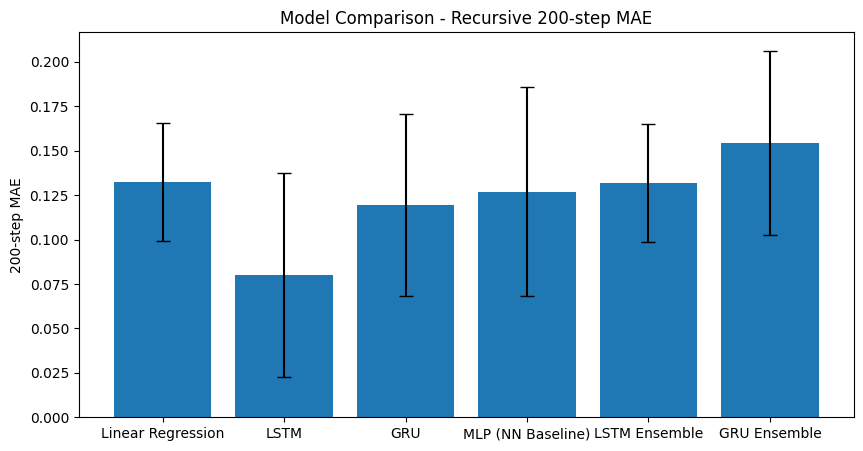

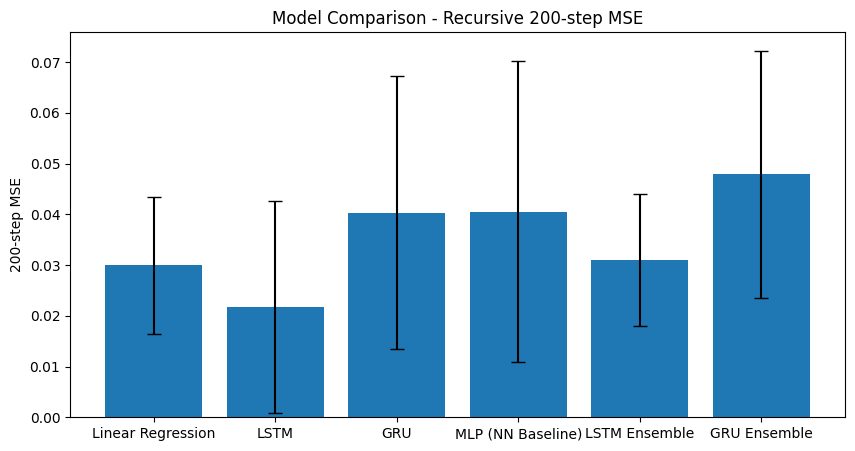

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

model_names = []
mae_means = []
mae_stds = []
mse_means = []
mse_stds = []

# calculate metrics
for r in results:

    maes = []
    mses = []

    for preds, true in zip(r["preds"], r["true"]):
        maes.append(mean_absolute_error(true, preds))
        mses.append(mean_squared_error(true, preds))

    model_names.append(r["name"])

    mae_means.append(np.mean(maes))
    mae_stds.append(np.std(maes))

    mse_means.append(np.mean(mses))
    mse_stds.append(np.std(mses))

    print(f"\n{r['name']}")
    print(f"200-step MAE: {np.mean(maes):.4f} +- {np.std(maes):.4f}")
    print(f"200-step MSE: {np.mean(mses):.4f} +- {np.std(mses):.4f}")


# -------------------------
# BAR PLOT: MAE
# -------------------------
plt.figure(figsize=(10, 5))

plt.bar(
    model_names,
    mae_means,
    yerr=mae_stds,
    capsize=5
)

plt.ylabel("200-step MAE")
plt.title("Model Comparison - Recursive 200-step MAE")

plt.show()


# -------------------------
# BAR PLOT: MSE
# -------------------------
plt.figure(figsize=(10, 5))

plt.bar(
    model_names,
    mse_means,
    yerr=mse_stds,
    capsize=5
)

plt.ylabel("200-step MSE")
plt.title("Model Comparison - Recursive 200-step MSE")

plt.show()

In [36]:
test_data = loadmat('Xtest.mat')

In [128]:
def test_model(config, n_runs=3):

    model_class = config["model_class"]
    model_kwargs = config["model_kwargs"]

    epochs = config["epochs"]
    lr = config["lr"]
    noise = config["noise"]

    window_size = config["window"]
    name = config["name"]

    ensemble_size = config.get("ensemble_size", 1)


    # Prepare training dataset
    train_series = pd.Series(data['Xtrain'].flatten())
    train_series = data_cleaning(train_series)

    X_train, Y_train = zip(*slices(train_series, window_size))

    X_train = np.array(X_train).reshape(-1, window_size, 1)
    Y_train = np.array(Y_train).reshape(-1, 1)

    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    Y_train = torch.tensor(Y_train, dtype=torch.float32).to(device)


    # Prepare TEST dataset
    test_series = pd.Series(test_data['Xtest'].flatten())
    test_series = data_cleaning(test_series)

    steps = len(test_series)

    # start recursive prediction from end of train set
    start_window = train_series[-window_size:].to_numpy()

    start_tensor = torch.tensor(start_window.reshape(window_size, 1),dtype=torch.float32).to(device)


    # Store run results
    experiment_maes = []
    experiment_mses = []

    all_predictions = []

    # multiple runs
    for run in range(n_runs):

        print(f"\n{name} - Run {run+1}/{n_runs}")

        models = []

        # different base seed per run
        base_seed = 1111 * (run + 1)

        # train model(s). ensemble_size=1 is single model
        for i in range(ensemble_size):

            seed = base_seed + i

            print(f"Training model seed {seed}")

            model_i = train_model(
                X_train,
                Y_train,

                # dummy validation
                X_train,
                Y_train,

                seed=seed,
                device=device,
                learning_rate=lr,
                epochs=epochs,
                model_class=model_class,
                model_kwargs=model_kwargs,
                noise=noise
            )

            models.append(model_i)

        # prediction
        preds = ensemble_recursive_predict(
            models,
            start_tensor,
            steps,
            device
        )

        mae = mean_absolute_error(test_series.values, preds)
        mse = mean_squared_error(test_series.values, preds)

        experiment_maes.append(mae)
        experiment_mses.append(mse)

        all_predictions.append(preds)

        print(f"  MAE: {mae:.4f}")
        print(f"  MSE: {mse:.4f}")

    #results
    return {
        "name": name,

        "mae_mean": np.mean(experiment_maes),
        "mae_std": np.std(experiment_maes),

        "mse_mean": np.mean(experiment_mses),
        "mse_std": np.std(experiment_mses),

        "predictions": all_predictions,
        "true": test_series
    }

In [153]:
n_runs = 10

models_to_compare = [
    {
        "name": "Linear Regression",
        "model_class": LinearRegressionModel,
        "model_kwargs": {},
        "epochs": 12500, #this isnt used by LinearRegression, but code needs a value
        "lr": 1e-2, #this isnt used by LinearRegression, but code needs a value
        "noise": 0, #this isnt used by LinearRegression, but code needs a value
        "window": 48,
        "ensemble_size": 1
    },
    {
        "name": "LSTM",
        "model_class": LSTMModel,
        "model_kwargs": {"hidden_size": 32, "num_layers": 2},
        "epochs": 12500,
        "lr": 1e-2,
        "noise": 0.1,
        "window": 32,
        "ensemble_size": 1
    },
    {
        "name": "GRU",
        "model_class": GRUModel,
        "model_kwargs": {"hidden_size": 64, "num_layers": 2},
        "epochs": 12500,
        "lr": 1e-2,
        "noise": 0.1,
        "window": 32,
        "ensemble_size": 1
    },
    {
        "name": "MLP (NN Baseline)",
        "model_class": BaselineNN,
        "model_kwargs": {"input_size": 16, "hidden_size": 32},
        "epochs": 12500,
        "lr": 1e-2,
        "noise": 0.0,
        "window": 16,
        "ensemble_size": 1
    },
    {
        "name": "LSTM Ensemble",
        "model_class": LSTMModel,
        "model_kwargs": {"hidden_size": 32, "num_layers": 1},
        "epochs": 1000,
        "lr": 1e-3,
        "noise": 0.1,
        "window": 16,
        "ensemble_size": 20
    },
    {
        "name": "GRU Ensemble",
        "model_class": GRUModel,
        "model_kwargs": {"hidden_size": 32, "num_layers": 1},
        "epochs": 1000,
        "lr": 1e-3,
        "noise": 0.1,
        "window": 16,
        "ensemble_size": 20
    }
]

results = []

for config in models_to_compare:

    result = test_model(config,n_runs)

    results.append(result)


Linear Regression - Run 1/10
Training model seed 1111
  MAE: 0.0935
  MSE: 0.0199

Linear Regression - Run 2/10
Training model seed 2222
  MAE: 0.0935
  MSE: 0.0199

Linear Regression - Run 3/10
Training model seed 3333
  MAE: 0.0935
  MSE: 0.0199

Linear Regression - Run 4/10
Training model seed 4444
  MAE: 0.0935
  MSE: 0.0199

Linear Regression - Run 5/10
Training model seed 5555
  MAE: 0.0935
  MSE: 0.0199

Linear Regression - Run 6/10
Training model seed 6666
  MAE: 0.0935
  MSE: 0.0199

Linear Regression - Run 7/10
Training model seed 7777
  MAE: 0.0935
  MSE: 0.0199

Linear Regression - Run 8/10
Training model seed 8888
  MAE: 0.0935
  MSE: 0.0199

Linear Regression - Run 9/10
Training model seed 9999
  MAE: 0.0935
  MSE: 0.0199

Linear Regression - Run 10/10
Training model seed 11110
  MAE: 0.0935
  MSE: 0.0199

LSTM - Run 1/10
Training model seed 1111
  MAE: 0.1394
  MSE: 0.0399

LSTM - Run 2/10
Training model seed 2222
  MAE: 0.1177
  MSE: 0.0333

LSTM - Run 3/10
Training mo

In [154]:
for r in results:

    print(f"\n{r['name']}")

    print(
        f"MAE: {r['mae_mean']:.4f} +- {r['mae_std']:.4f}"
    )

    print(
        f"MSE: {r['mse_mean']:.4f} +- {r['mse_std']:.4f}"
    )


Linear Regression
MAE: 0.0935 +- 0.0000
MSE: 0.0199 +- 0.0000

LSTM
MAE: 0.1072 +- 0.0306
MSE: 0.0288 +- 0.0134

GRU
MAE: 0.1199 +- 0.0416
MSE: 0.0380 +- 0.0267

MLP (NN Baseline)
MAE: 0.1706 +- 0.0254
MSE: 0.0570 +- 0.0136

LSTM Ensemble
MAE: 0.1421 +- 0.0279
MSE: 0.0403 +- 0.0098

GRU Ensemble
MAE: 0.1801 +- 0.0031
MSE: 0.0570 +- 0.0018


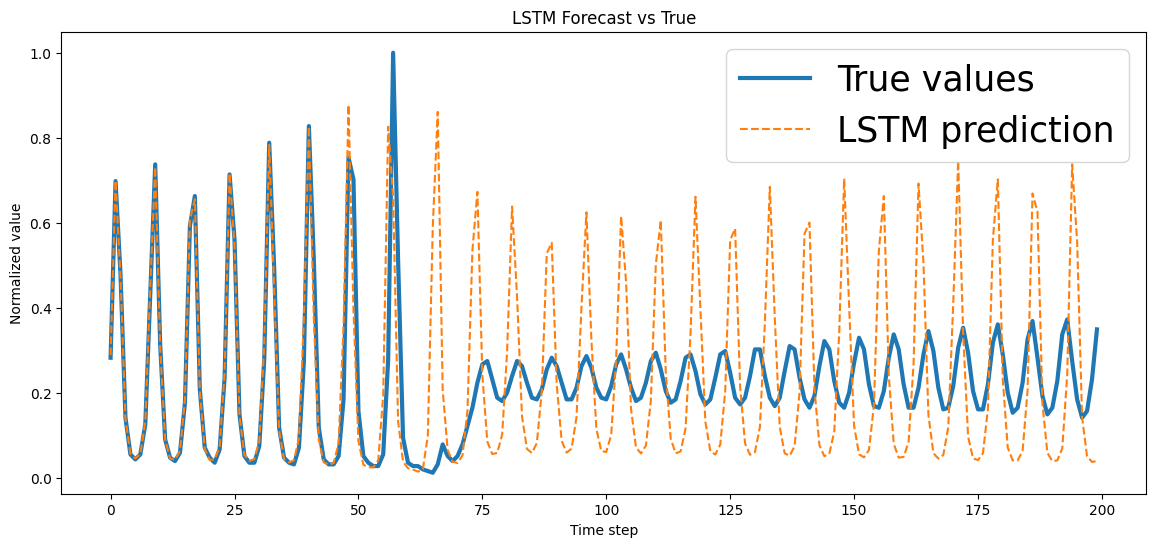

In [208]:
import matplotlib.pyplot as plt

model_name = "LSTM"  # choose what you want to plot

r = next(res for res in results if res["name"] == model_name)

plt.figure(figsize=(14, 6))

t = range(len(r["true"]))

# true values
plt.plot(
    t,
    r["true"],
    label="True values",
    linewidth=3
)

# pick one run
preds = r["predictions"][0]

plt.plot(
    t,
    preds,
    linestyle="--",
    label=f"{model_name} prediction"
)

plt.title(f"{model_name} Forecast vs True")
plt.xlabel("Time step")
plt.ylabel("Normalized value")
plt.legend(fontsize=25)
plt.show()